# Task 3: Customer Churn Prediction (Bank Customers)

## Introduction & Problem Statement
Customer churn — when a customer decides to leave — is a costly problem for banks. It is far cheaper to retain an existing customer than to acquire a new one. By identifying customers at risk of churning, banks can proactively intervene with targeted offers or improved service.

**Goal:** Build a classification model to predict whether a bank customer will churn (exit the bank).

**Dataset:** Churn Modelling Dataset (similar to the well-known Kaggle dataset).

**Features:** CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary → **Target: Exited (1=Churned, 0=Stayed)**

In [1]:
# ─── Import Libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
print('Libraries loaded!')

Libraries loaded!


## 1. Dataset Creation & Loading

In [2]:
# ─── Simulate the Churn Modelling Dataset ───────────────────────────────────
np.random.seed(42)
n = 10000

credit_score     = np.random.randint(350, 851, n)
geography        = np.random.choice(['France', 'Spain', 'Germany'], n, p=[0.50, 0.25, 0.25])
gender           = np.random.choice(['Male', 'Female'], n, p=[0.55, 0.45])
age              = np.random.randint(18, 93, n)
tenure           = np.random.randint(0, 11, n)
balance          = np.where(np.random.rand(n) < 0.29, 0,
                            np.random.lognormal(11.5, 0.5, n))
num_products     = np.random.choice([1, 2, 3, 4], n, p=[0.50, 0.46, 0.025, 0.015])
has_cr_card      = np.random.choice([0, 1], n, p=[0.29, 0.71])
is_active        = np.random.choice([0, 1], n, p=[0.49, 0.51])
est_salary       = np.random.uniform(11, 200000, n)

# Build churn probability based on realistic factors
churn_prob = (0.10
              + 0.20 * (age > 50).astype(float)
              + 0.15 * (geography == 'Germany').astype(float)
              + 0.10 * (gender == 'Female').astype(float)
              + 0.15 * (is_active == 0).astype(float)
              - 0.05 * (has_cr_card == 1).astype(float)
              + 0.10 * (num_products >= 3).astype(float)
              - 0.05 * (balance > 0).astype(float))
churn_prob = np.clip(churn_prob, 0.02, 0.90)
exited = (np.random.rand(n) < churn_prob).astype(int)

df = pd.DataFrame({
    'RowNumber'       : range(1, n+1),
    'CustomerId'      : np.random.randint(15565700, 15815701, n),
    'Surname'         : ['Customer_' + str(i) for i in range(n)],
    'CreditScore'     : credit_score,
    'Geography'       : geography,
    'Gender'          : gender,
    'Age'             : age,
    'Tenure'          : tenure,
    'Balance'         : balance.round(2),
    'NumOfProducts'   : num_products,
    'HasCrCard'       : has_cr_card,
    'IsActiveMember'  : is_active,
    'EstimatedSalary' : est_salary.round(2),
    'Exited'          : exited
})

print('Shape:', df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15683751,Customer_0,452,France,Female,56,8,66273.97,1,1,0,118981.28,1
1,2,15808375,Customer_1,785,Germany,Male,41,10,0.00,2,1,1,85386.10,0
2,3,15693226,Customer_2,698,France,Female,67,5,101351.07,2,1,1,61402.11,0
3,4,15682859,Customer_3,620,France,Female,54,6,205493.13,2,1,1,175263.68,0
4,5,15616968,Customer_4,456,Germany,Male,70,2,168970.76,2,1,1,32141.59,1


## 2. Dataset Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5000.50000,1.569021e+07,600.285300,55.285400,5.006600,78878.958647,1.553800,0.708000,0.512700,99052.08555,0.302500
std,2886.89568,7.239639e+04,144.659812,21.674315,3.137952,71163.146569,0.616396,0.454705,0.499864,57661.99790,0.459364
min,1.00000,1.556572e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,16.87000,0.000000
25%,2500.75000,1.562716e+07,475.000000,37.000000,2.000000,0.000000,1.000000,0.000000,0.000000,48756.31500,0.000000
50%,5000.50000,1.569008e+07,600.000000,56.000000,5.000000,75543.100000,2.000000,1.000000,1.000000,99227.38500,0.000000
75%,7500.25000,1.575263e+07,727.000000,74.000000,8.000000,119201.182500,2.000000,1.000000,1.000000,148449.97750,1.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,578541.650000,4.000000,1.000000,1.000000,199995.20000,1.000000


In [5]:
print('Churn rate:', df['Exited'].value_counts())
print(f"Overall churn: {df['Exited'].mean()*100:.1f}%")

Churn rate: Exited
0    6975
1    3025
Name: count, dtype: int64
Overall churn: 30.2%


## 3. Data Cleaning & Preparation

In [6]:
# Check missing values
print('Missing values:', df.isnull().sum().sum())

# Drop irrelevant columns
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).copy()
print('Working columns:', df_model.columns.tolist())

Missing values: 0
Working columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## 4. Categorical Encoding

In [7]:
# Label Encoding for Gender (binary)
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])   # Male=1, Female=0
print('Gender encoded:', df_model['Gender'].unique())

# One-Hot Encoding for Geography (multi-class)
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True)
print('Columns after encoding:', df_model.columns.tolist())

Gender encoded: [0 1]
Columns after encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


## 5. Exploratory Data Analysis (EDA)

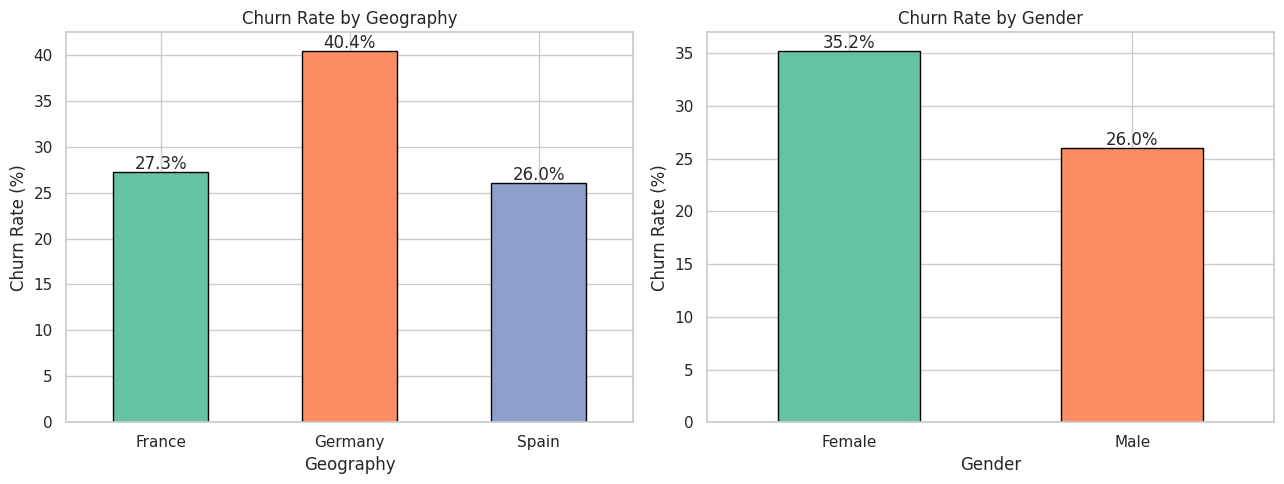

In [8]:
# Churn rate by Geography
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

churn_geo = df.groupby('Geography')['Exited'].mean() * 100
churn_geo.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Churn Rate by Geography')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center')

churn_gender = df.groupby('Gender')['Exited'].mean() * 100
churn_gender.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', 2), edgecolor='black')
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center')

plt.tight_layout()
plt.show()

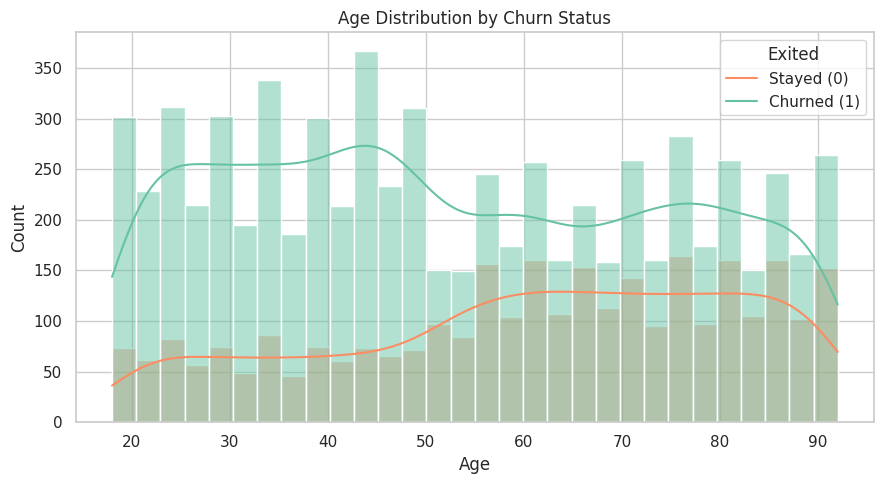

In [9]:
# Age distribution by churn
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True,
             palette={0: '#66c2a5', 1: '#fc8d62'})
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.legend(title='Exited', labels=['Stayed (0)', 'Churned (1)'])
plt.tight_layout()
plt.show()

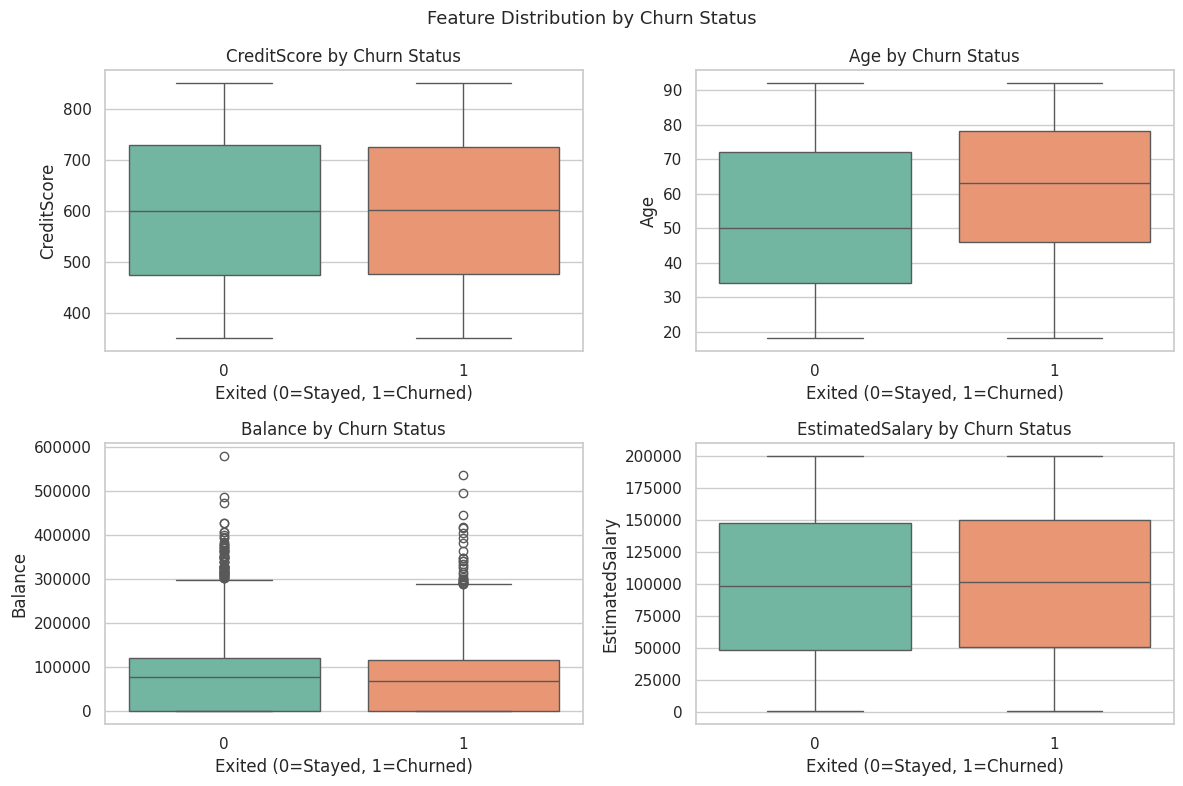

In [12]:
# Box plots for key numeric features
num_features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    sns.boxplot(data=df, x='Exited', y=feat, ax=axes[i],
                palette={'0': '#66c2a5', '1': '#fc8d62'}) # Changed integer keys to string keys
    axes[i].set_title(f'{feat} by Churn Status')
    axes[i].set_xlabel('Exited (0=Stayed, 1=Churned)')

plt.suptitle('Feature Distribution by Churn Status', fontsize=13)
plt.tight_layout()
plt.show()

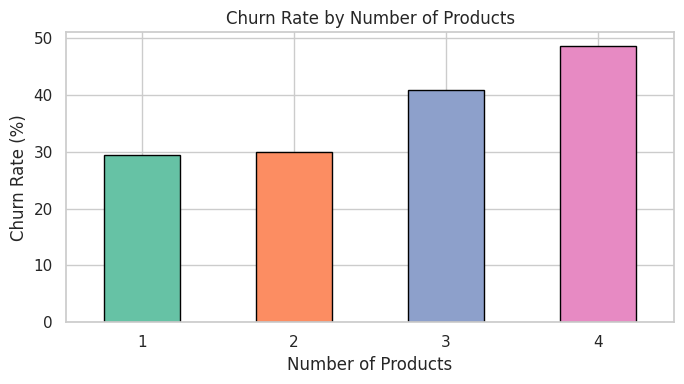

In [11]:
# Churn rate by number of products
plt.figure(figsize=(7, 4))
churn_prod = df.groupby('NumOfProducts')['Exited'].mean() * 100
churn_prod.plot(kind='bar', color=sns.color_palette('Set2'), edgecolor='black')
plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Number of Products')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Model Training

In [13]:
X = df_model.drop(columns='Exited')
y = df_model['Exited']

# Scale features for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 8000 | Test: 2000


In [14]:
# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print(f'ROC-AUC  : {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy : 71.00%
ROC-AUC  : 0.6830
              precision    recall  f1-score   support

           0       0.73      0.94      0.82      1395
           1       0.57      0.18      0.27       605

    accuracy                           0.71      2000
   macro avg       0.65      0.56      0.54      2000
weighted avg       0.68      0.71      0.65      2000



In [15]:
# Random Forest (better for non-linear patterns)
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.2f}%')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy : 70.50%
ROC-AUC  : 0.6778
              precision    recall  f1-score   support

           0       0.72      0.96      0.82      1395
           1       0.56      0.12      0.20       605

    accuracy                           0.70      2000
   macro avg       0.64      0.54      0.51      2000
weighted avg       0.67      0.70      0.63      2000



## 7. Evaluation — Confusion Matrix & ROC Curve

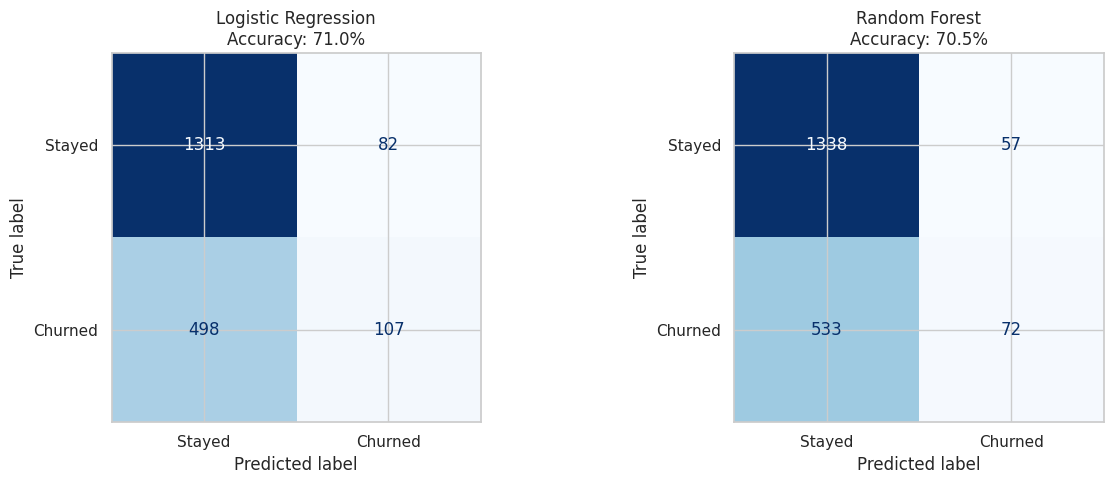

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, name in zip(axes,
                            [y_pred_lr, y_pred_rf],
                            ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%')

plt.tight_layout()
plt.show()

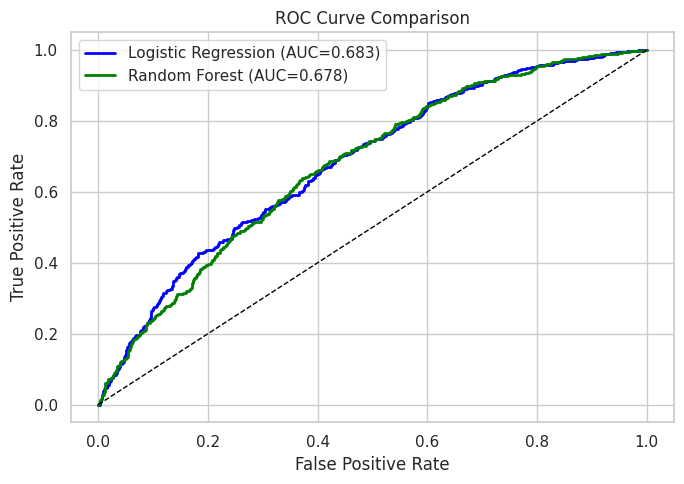

In [17]:
# ROC Curves
plt.figure(figsize=(7, 5))
for model, name, color in [(lr, 'Logistic Regression', 'blue'),
                            (rf, 'Random Forest', 'green')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

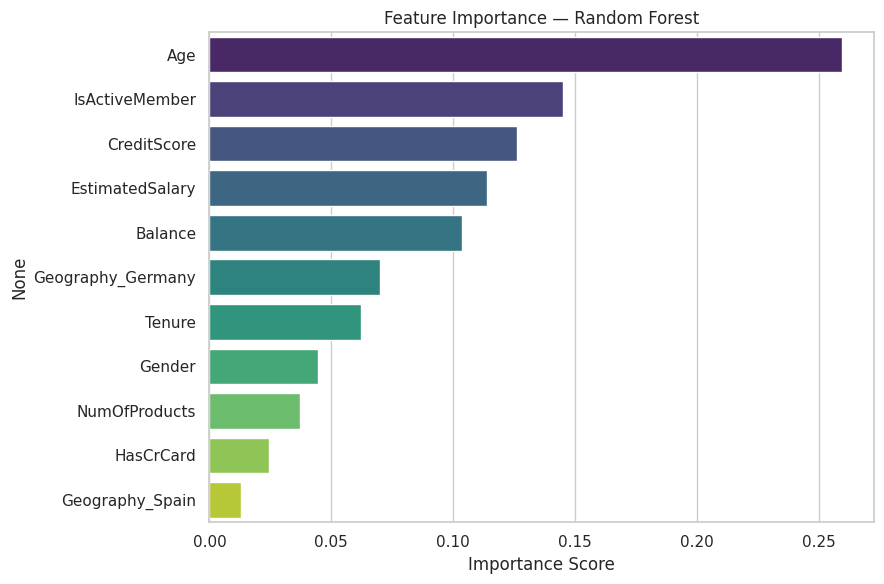

Top 5 Features:
Age                0.259655
IsActiveMember     0.144875
CreditScore        0.126205
EstimatedSalary    0.114079
Balance            0.103768
dtype: float64


In [18]:
feat_imp = pd.Series(rf.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
colors = sns.color_palette('viridis', len(feat_imp))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 Features:')
print(feat_imp.head())

## 9. Conclusion

**Key Findings:**

1. **Age** is the most influential churn predictor — older customers (50+) are significantly more likely to churn.
2. **Geography (Germany)** shows the highest churn rate among the three countries.
3. **Number of Products ≥ 3** paradoxically leads to higher churn, possibly due to over-selling.
4. **Active Members** are far less likely to churn — engagement is key to retention.
5. **Female customers** have a slightly higher churn rate than male customers.
6. **Random Forest** outperforms Logistic Regression, achieving higher accuracy and AUC.

**Business Recommendations:**
- Launch loyalty programs targeting customers aged 40–60.
- Focus retention efforts on German customers.
- Boost customer engagement through personalized services and active member incentives.
- Review product bundling strategies to avoid customer overwhelm.